**PRACTICAL EXAMPLES**



**PROJECT 1: Linear Regression**

Epoch 0: Loss = 41.054939
Epoch 50: Loss = 0.462141
Epoch 100: Loss = 0.304091
Epoch 150: Loss = 0.282212
Epoch 200: Loss = 0.279183
Epoch 250: Loss = 0.278764
Epoch 300: Loss = 0.278705
Epoch 350: Loss = 0.278697
Epoch 400: Loss = 0.278696
Epoch 450: Loss = 0.278696

Final parameters: w = 2.5107, b = 1.0114
True parameters: w = 2.5, b = 1.0


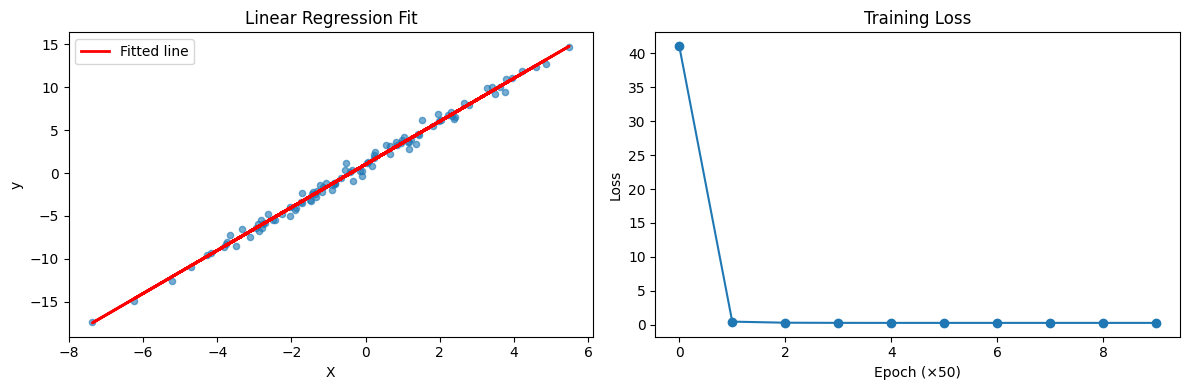

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, value_and_grad
import matplotlib.pyplot as plt

# 1. Generate synthetic data
key = jax.random.PRNGKey(42)
key, subkey = jax.random.split(key)

X_train = jax.random.normal(subkey, (100, 1)) * 3
y_train = 2.5 * X_train + 1.0 + jax.random.normal(jax.random.split(key)[1], (100, 1)) * 0.5

# 2. Define model and loss
def predict(params, x):
    w, b = params
    return w * x + b

def loss_fn(params, x, y):
    y_pred = predict(params, x)
    return jnp.mean((y_pred - y)**2)

# 3. Initialize parameters
params = (jnp.array(0.0), jnp.array(0.0))

# 4. JIT-compiled training step
@jit
def train_step(params, x, y, learning_rate):
    loss, grads = value_and_grad(loss_fn)(params, x, y)
    w_grad, b_grad = grads
    w, b = params

    new_params = (
        w - learning_rate * w_grad,
        b - learning_rate * b_grad
    )
    return new_params, loss

# 5. Training loop
learning_rate = 0.01
losses = []

for epoch in range(500):
    params, loss = train_step(params, X_train, y_train, learning_rate)
    if epoch % 50 == 0:
        losses.append(float(loss))
        print(f"Epoch {epoch}: Loss = {loss:.6f}")

# 6. Results
w_final, b_final = params
print(f"\nFinal parameters: w = {float(w_final):.4f}, b = {float(b_final):.4f}")
print(f"True parameters: w = 2.5, b = 1.0")

# 7. Visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, s=20)
plt.plot(X_train, predict(params, X_train), 'r-', lw=2, label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression Fit')

plt.subplot(1, 2, 2)
plt.plot(losses, marker='o')
plt.xlabel('Epoch (×50)')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.tight_layout()
plt.savefig('linear_regression_results.png')
plt.show()

**PROJECT 2: Neural Network Classifier**

Epoch 10: Loss = 1.0903, Accuracy = 0.3850
Epoch 20: Loss = 1.0942, Accuracy = 0.3850
Epoch 30: Loss = 1.0892, Accuracy = 0.3850
Epoch 40: Loss = 1.0943, Accuracy = 0.3850
Epoch 50: Loss = 1.0936, Accuracy = 0.3850

Final Training Accuracy: 0.3850


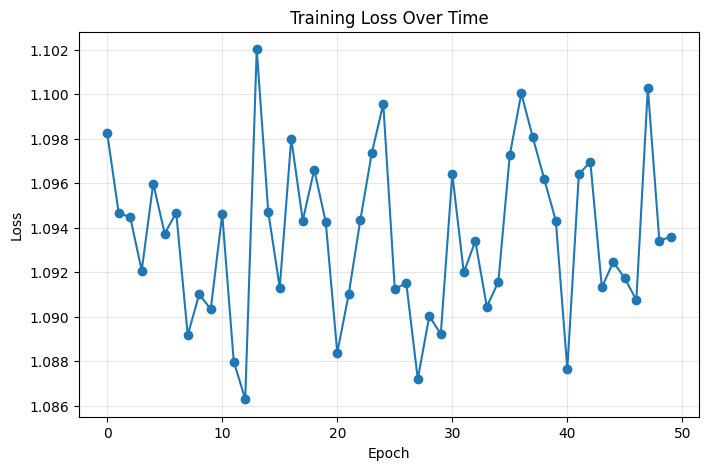

In [2]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, value_and_grad
from jax.nn import relu, softmax, log_softmax
import numpy as np

# 1. Generate synthetic dataset
key = jax.random.PRNGKey(0)
n_samples = 200
n_features = 10
n_classes = 3

key, subkey1, subkey2 = jax.random.split(key, 3)
X = jax.random.normal(subkey1, (n_samples, n_features))
y = jax.random.randint(subkey2, (n_samples,), 0, n_classes)

# 2. Define neural network
def init_network_params(key, layer_sizes):
    """Initialize network parameters"""
    params = []
    for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)
        w = jax.random.normal(subkey, (in_size, out_size)) * 0.01
        b = jnp.zeros(out_size)
        params.append({'w': w, 'b': b})
    return params

layer_sizes = [n_features, 64, 32, n_classes]
params = init_network_params(key, layer_sizes)

# 3. Forward pass
def forward(params, x):
    """Forward pass through network"""
    for i, layer_params in enumerate(params[:-1]):
        x = jnp.dot(x, layer_params['w']) + layer_params['b']
        x = relu(x)

    # Output layer
    x = jnp.dot(x, params[-1]['w']) + params[-1]['b']
    return log_softmax(x)

# 4. Loss function
def loss_fn(params, x, y):
    logits = forward(params, x)
    return -logits[y]  # Cross-entropy

# 5. Batched loss and gradient
def batch_loss(params, xs, ys):
    losses = vmap(lambda x, y: loss_fn(params, x, y))(xs, ys)
    return jnp.mean(losses)

@jit
def train_step(params, xs, ys, learning_rate):
    loss, grads = value_and_grad(batch_loss)(params, xs, ys)

    # Update parameters
    new_params = []
    for layer_params, layer_grads in zip(params, grads):
        new_layer = {
            'w': layer_params['w'] - learning_rate * layer_grads['w'],
            'b': layer_params['b'] - learning_rate * layer_grads['b']
        }
        new_params.append(new_layer)

    return new_params, loss

# 6. Accuracy function
def accuracy(params, xs, ys):
    predictions = vmap(lambda x: jnp.argmax(forward(params, x)))(xs)
    return jnp.mean(predictions == ys)

# 7. Training loop
learning_rate = 0.1
batch_size = 32
n_epochs = 50
losses = []

for epoch in range(n_epochs):
    # Shuffle data
    indices = np.random.permutation(len(X))

    epoch_loss = 0
    n_batches = 0

    for i in range(0, len(X), batch_size):
        batch_idx = indices[i:i+batch_size]
        xs = X[batch_idx]
        ys = y[batch_idx]

        params, loss = train_step(params, xs, ys, learning_rate)
        epoch_loss += loss
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses.append(float(avg_loss))

    if (epoch + 1) % 10 == 0:
        train_acc = accuracy(params, X, y)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {float(train_acc):.4f}")

# 8. Results
final_acc = accuracy(params, X, y)
print(f"\nFinal Training Accuracy: {float(final_acc):.4f}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.savefig('neural_network_loss.png')
plt.show()

**PROJECT 3: Gradient Descent Visualization**

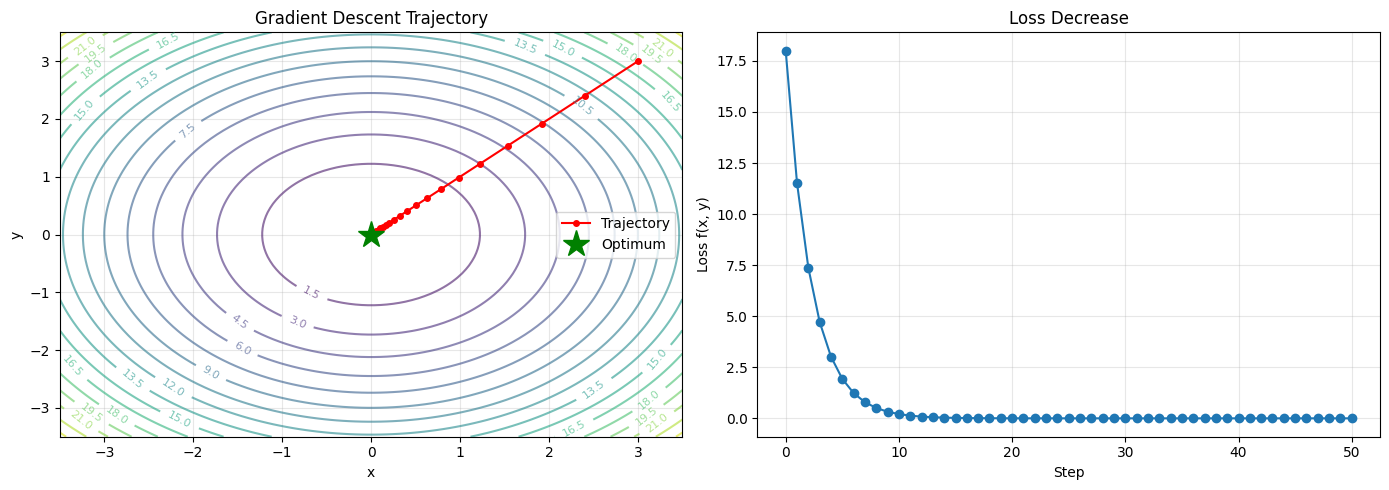

Final point: [4.281743e-05 4.281743e-05]
Final loss: 0.000000


In [3]:
import jax
import jax.numpy as jnp
from jax import grad
import matplotlib.pyplot as plt

# Simple quadratic function: f(x, y) = x^2 + y^2
def f(xy):
    x, y = xy
    return x**2 + y**2

grad_f = grad(f)

# Gradient descent optimization
x0 = jnp.array([3.0, 3.0])
learning_rate = 0.1
n_steps = 50

trajectory = [x0]
losses = [float(f(x0))]

x = x0
for step in range(n_steps):
    gradient = grad_f(x)
    x = x - learning_rate * gradient
    trajectory.append(x)
    losses.append(float(f(x)))

trajectory = jnp.array(trajectory)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D contour plot
ax = axes[0]
x_range = jnp.linspace(-3.5, 3.5, 100)
y_range = jnp.linspace(-3.5, 3.5, 100)
X, Y = jnp.meshgrid(x_range, y_range)
Z = X**2 + Y**2

contour = ax.contour(X, Y, Z, levels=20, alpha=0.6)
ax.clabel(contour, inline=True, fontsize=8)
ax.plot(trajectory[:, 0], trajectory[:, 1], 'ro-', markersize=4, label='Trajectory')
ax.plot(0, 0, 'g*', markersize=20, label='Optimum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gradient Descent Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss over time
ax = axes[1]
ax.plot(losses, marker='o')
ax.set_xlabel('Step')
ax.set_ylabel('Loss f(x, y)')
ax.set_title('Loss Decrease')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_descent_visualization.png')
plt.show()

print(f"Final point: {trajectory[-1]}")
print(f"Final loss: {losses[-1]:.6f}")

**EMBEDDED ML APPLICATIONS**

**Lightweight Model for Edge Devices**

In [4]:
import jax
import jax.numpy as jnp
from jax import jit
import time

# Create small model suitable for embedded devices
def create_lightweight_model():
    """Small neural network for edge inference"""
    key = jax.random.PRNGKey(0)

    # Much smaller than standard models
    params = {
        'w1': jax.random.normal(key, (784, 32)) * 0.01,
        'b1': jnp.zeros(32),
        'w2': jax.random.normal(key, (32, 10)) * 0.01,
        'b2': jnp.zeros(10)
    }

    return params

params = create_lightweight_model()

# Fast inference
@jit
def inference(params, x):
    """Ultra-fast inference"""
    x = jnp.maximum(0, jnp.dot(x, params['w1']) + params['b1'])
    return jnp.dot(x, params['w2']) + params['b2']

# Benchmark
x_test = jax.random.normal(jax.random.PRNGKey(1), (784,))

# Warmup
_ = inference(params, x_test)

# Time inference
start = time.time()
for _ in range(10000):
    _ = inference(params, x_test)
elapsed = time.time() - start

# Model statistics
total_params = sum(p.size for p in params.values())
model_size_kb = (total_params * 4) / 1024

print(f"Model Statistics:")
print(f"Total parameters: {total_params:,}")
print(f"Model size: {model_size_kb:.2f} KB")
print(f"\nPerformance:")
print(f"Inference time: {(elapsed/10000)*1000:.3f} ms")
print(f"Throughput: {10000/elapsed:.0f} samples/sec")

Model Statistics:
Total parameters: 25,450
Model size: 99.41 KB

Performance:
Inference time: 0.026 ms
Throughput: 38201 samples/sec


**Model Quantization for Even Smaller Size**

In [5]:
def quantize_params(params, bits=8):
    """Quantize parameters to reduce memory"""
    quantized = {}

    for name, param in params.items():
        # Find max value for scaling
        p_max = jnp.max(jnp.abs(param))

        # Scale to range [-2^(bits-1), 2^(bits-1)-1]
        scale = (2**(bits-1) - 1) / p_max

        # Quantize
        p_quantized = (param * scale).astype(jnp.int8)

        quantized[name] = (p_quantized, scale)

    return quantized

# Example usage
quantized_params = quantize_params(params, bits=8)

# Dequantize for inference
def dequantize_params(quantized_params):
    dequantized = {}
    for name, (p_q, scale) in quantized_params.items():
        dequantized[name] = p_q.astype(jnp.float32) / scale
    return dequantized

# Original size
original_size = sum(p.size for p in params.values()) * 4  # 4 bytes per float32

# Quantized size
quantized_size = sum(p[0].size for p in quantized_params.values()) * 1  # 1 byte per int8

print(f"Original size: {original_size / 1024:.2f} KB")
print(f"Quantized size: {quantized_size / 1024:.2f} KB")
print(f"Compression ratio: {original_size / quantized_size:.1f}x")

Original size: 99.41 KB
Quantized size: 24.85 KB
Compression ratio: 4.0x


**Efficient Batch Inference**

In [6]:
from jax import vmap

# Vectorized inference for batch
@jit
def batch_inference(params, x_batch):
    """Process batch of samples efficiently"""
    def single_inference(x):
        return inference(params, x)

    return vmap(single_inference)(x_batch)

# Benchmark batch inference
batch_size = 32
x_batch = jax.random.normal(jax.random.PRNGKey(1), (batch_size, 784))

_ = batch_inference(params, x_batch)  # Warmup

start = time.time()
for _ in range(100):
    _ = batch_inference(params, x_batch)
elapsed = time.time() - start

throughput = (100 * batch_size) / elapsed
print(f"Batch inference throughput: {throughput:.0f} samples/sec")
print(f"Average latency per sample: {(elapsed/(100*batch_size))*1000:.3f} ms")

Batch inference throughput: 463619 samples/sec
Average latency per sample: 0.002 ms
